<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/EMG_Aplicaci%C3%B3n_Movimiento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 44.6 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.6.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.


In [2]:
import numpy as np
import wfdb
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

Paso 1: Cargando registro de PhysioNet...
Generating record list for: emg_healthy
Generating list of all files for: emg_healthy
Finished downloading files
-> Mostrando Gráfica 1. Cierra la ventana para avanzar.


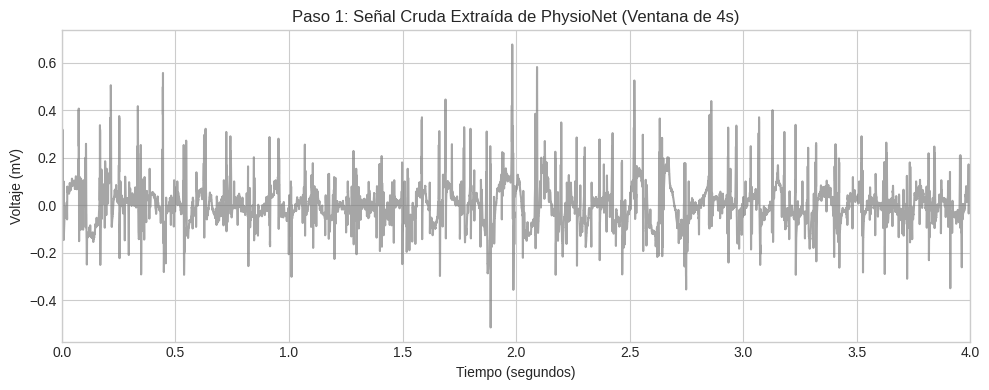

In [3]:
# Configuración de estilo visual
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# 1. CARGA DE DATOS REALES DE PHYSIONET

print("Paso 1: Cargando registro de PhysioNet...")
record_name = 'emg_healthy'
wfdb.dl_database('emgdb', dl_dir='.', records=[record_name], overwrite=False)

record = wfdb.rdrecord(record_name)
emg_raw = record.p_signal[:, 0]
fs = record.fs
t = np.arange(len(emg_raw)) / fs

# Definimos los límites estrictos de visualización (Bloque de 4 segundos)
t_start, t_end = 8.0, 12.0
signal_mask = (t >= t_start) & (t <= t_end)

t_vis = t[signal_mask] - t_start  # Normalizado a escala 0 - 4 segundos
emg_raw_vis = emg_raw[signal_mask]

# --- GRÁFICA PASO 1: Señal Cruda a Escala ---
plt.figure(figsize=(10, 4))
plt.plot(t_vis, emg_raw_vis, color='gray', alpha=0.7)
plt.title('Paso 1: Señal Cruda Extraída de PhysioNet (Ventana de 4s)')
plt.xlabel('Tiempo (segundos)')
plt.ylabel('Voltaje (mV)')
plt.xlim(0, 4)
plt.tight_layout()
print("-> Mostrando Gráfica 1. Cierra la ventana para avanzar.")
plt.show()


Paso 2: Filtrando la señal...
-> Mostrando Gráfica 2. Cierra la ventana para avanzar.


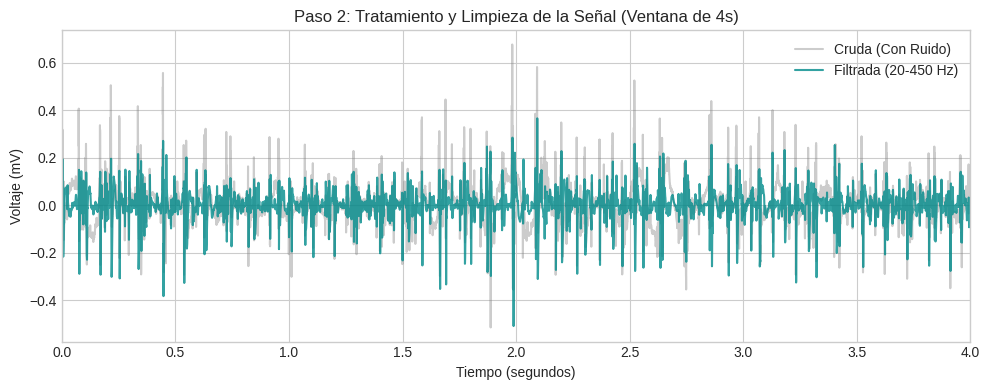

In [4]:
# 2. TRATAMIENTO DE LA SEÑAL (FILTRADO)

print("\nPaso 2: Filtrando la señal...")
def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return lfilter(b, a, data)

emg_filtered = butter_bandpass_filter(emg_raw, lowcut=20.0, highcut=450.0, fs=fs)
emg_filt_vis = emg_filtered[signal_mask]

# --- GRÁFICA PASO 2: Comparación del Filtrado a Escala ---
plt.figure(figsize=(10, 4))
plt.plot(t_vis, emg_raw_vis, color='gray', alpha=0.4, label='Cruda (Con Ruido)')
plt.plot(t_vis, emg_filt_vis, color='darkcyan', alpha=0.8, label='Filtrada (20-450 Hz)')
plt.title('Paso 2: Tratamiento y Limpieza de la Señal (Ventana de 4s)')
plt.xlabel('Tiempo (segundos)')
plt.ylabel('Voltaje (mV)')
plt.xlim(0, 4)
plt.legend(loc='upper right')
plt.tight_layout()
print("-> Mostrando Gráfica 2. Cierra la ventana para avanzar.")
plt.show()


Paso 3: Segmentando en ventanas y extrayendo características...
-> Mostrando Gráfica 3. Cierra la ventana para avanzar.


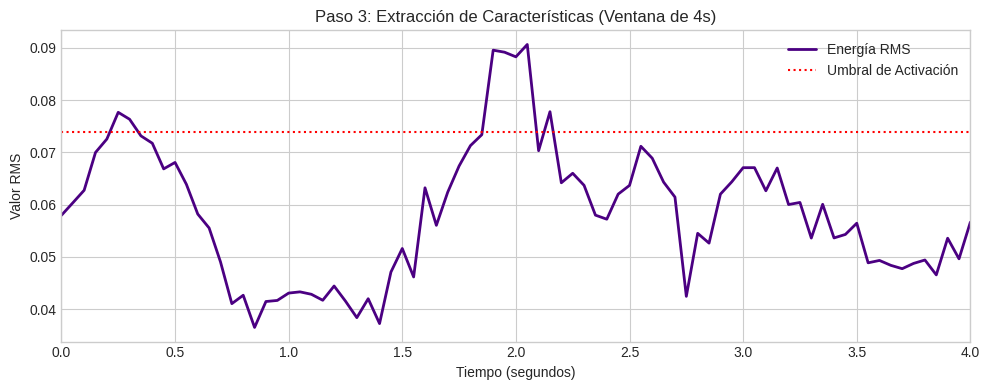

In [5]:
# 3. VENTANEO Y EXTRACCIÓN DE CARACTERÍSTICAS

print("\nPaso 3: Segmentando en ventanas y extrayendo características...")
window_size = int(0.2 * fs)
step_size = int(0.05 * fs)

features = []
labels = []
window_times = []

rms_global = np.sqrt(np.mean(emg_filtered**2))
threshold = rms_global * 1.2

for start in range(0, len(emg_filtered) - window_size, step_size):
    end = start + window_size
    window = emg_filtered[start:end]

    rms = np.sqrt(np.mean(window**2))
    mav = np.mean(np.abs(window))
    var = np.var(window)

    features.append([rms, mav, var])
    window_times.append(t[start + window_size // 2])

    if rms > threshold:
        labels.append(1)
    else:
        labels.append(0)

X = np.array(features)
y = np.array(labels)
window_times = np.array(window_times)

# Filtramos las características calculadas para que correspondan exactamente al mismo bloque
test_mask = (window_times >= t_start) & (window_times <= t_end)
X_vis_features = X[test_mask]
test_times_vis = window_times[test_mask] - t_start

# --- GRÁFICA PASO 3: Curva de Características a Escala ---
plt.figure(figsize=(10, 4))
plt.plot(test_times_vis, X_vis_features[:, 0], color='indigo', linewidth=2, label='Energía RMS')
plt.axhline(y=threshold, color='red', linestyle=':', label='Umbral de Activación')
plt.title('Paso 3: Extracción de Características (Ventana de 4s)')
plt.xlabel('Tiempo (segundos)')
plt.ylabel('Valor RMS')
plt.xlim(0, 4)
plt.legend(loc='upper right')
plt.tight_layout()
print("-> Mostrando Gráfica 3. Cierra la ventana para avanzar.")
plt.show()


Paso 4 y 5: Entrenando IA y evaluando resultados...
Precisión alcanzada por la IA: 100.00%
-> Mostrando Gráfica de Validación Combinada.


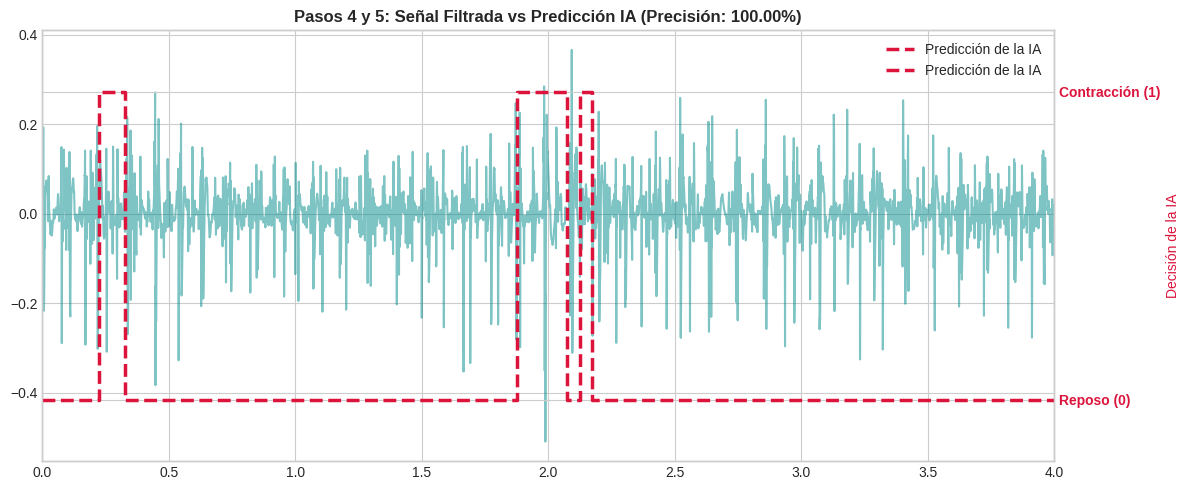

In [6]:
# 4 y 5. ENTRENAMIENTO Y CLASIFICACIÓN FINAL

print("\nPaso 4 y 5: Entrenando IA y evaluando resultados...")
# Usamos el resto de los datos (fuera de la ventana de evaluación) para entrenar el modelo
train_mask = (window_times < t_start) | (window_times > t_end)

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

# Entrenar clasificador
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predicción
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión alcanzada por la IA: {accuracy * 100:.2f}%")

# Interpolación de activación real para el fondo visual
activation_vis = np.array([
    1 if np.sqrt(np.mean(emg_filtered[max(0, int(idx-fs*0.1)):min(len(emg_filtered), int(idx+fs*0.1))]**2)) > threshold else 0
    for idx in np.where(signal_mask)[0]
])

# --- GRÁFICA PASO 4 y 5: Señal Combinada y Predicción a Escala ---
plt.figure(figsize=(12, 5))

# Capa de fondo: Movimiento Real (EMG filtrada)
plt.plot(t_vis, emg_filt_vis, color='darkcyan', alpha=0.5, label='EMG Filtrada (Movimiento Real)')

# Capa secundaria: Decisión binaria de la IA a la derecha
ax2 = plt.gca().twinx()
ax2.step(test_times_vis, y_pred, where='mid', color='crimson', linestyle='--', linewidth=2.5, label='Predicción de la IA')

# Ajustes de formato e ID de escalas en X fijas de 0 a 4
plt.title(f'Pasos 4 y 5: Señal Filtrada vs Predicción IA (Precisión: {accuracy*100:.2f}%)', fontsize=12, fontweight='bold')
plt.gca().set_xlabel('Tiempo del segmento analizado (segundos)')
plt.gca().set_ylabel('Voltaje EMG (mV)', color='darkcyan')
plt.gca().set_xlim(0, 4)
ax2.set_ylabel('Decisión de la IA', color='crimson')

ax2.set_ylim(-0.2, 1.2)
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Reposo (0)', 'Contracción (1)'], color='crimson', fontweight='bold')

# Mezclar leyendas
lines, labels_leg = plt.gca().get_legend_handles_labels()
lines2, labels_leg2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels_leg + labels_leg2, loc='upper right')

plt.tight_layout()
print("-> Mostrando Gráfica de Validación Combinada.")
plt.show()


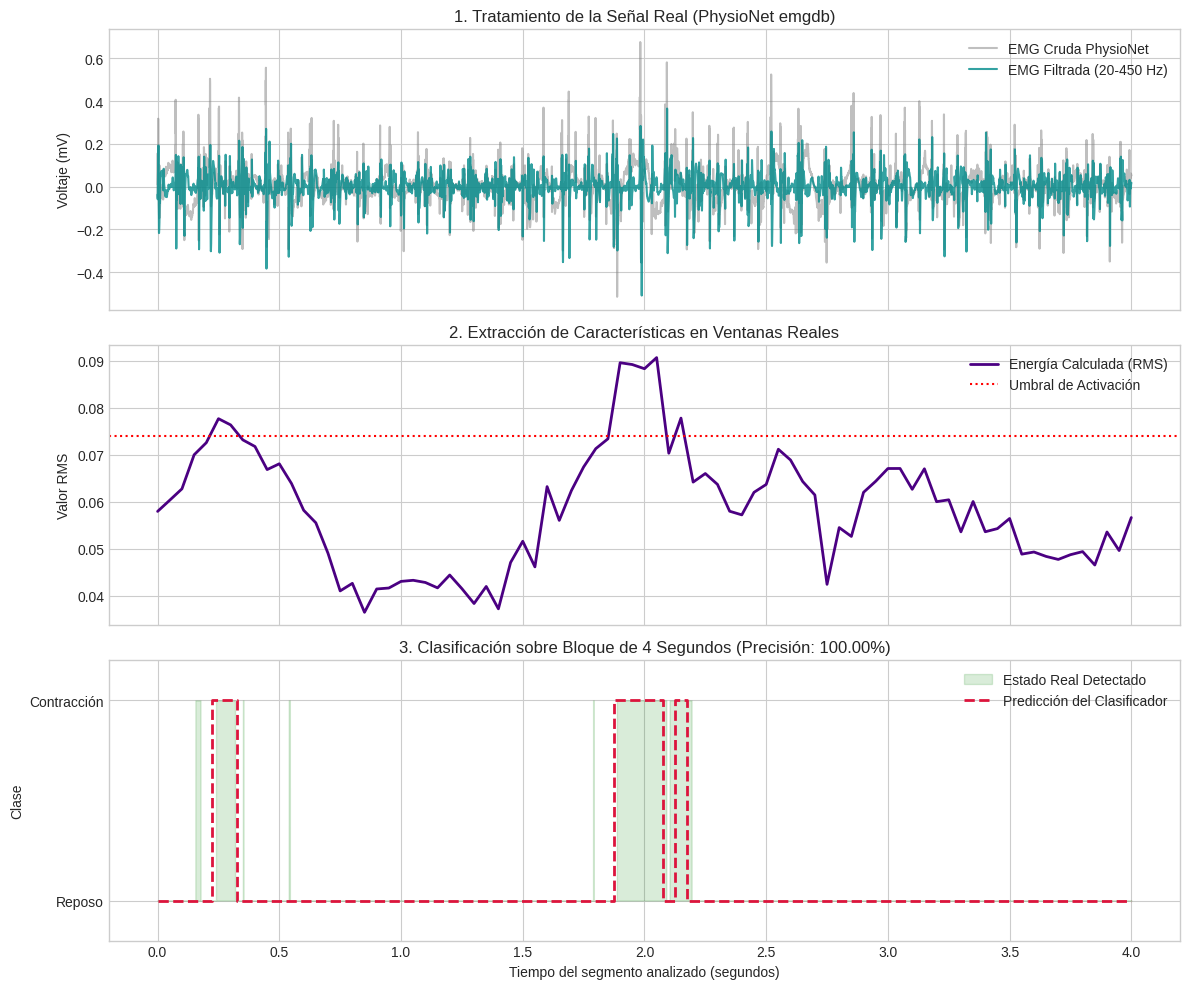

In [7]:
# Graficar
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Panel 1: Tratamiento de datos reales
axs[0].plot(t_vis, emg_raw_vis, color='gray', alpha=0.5, label='EMG Cruda PhysioNet')
axs[0].plot(t_vis, emg_filt_vis, color='darkcyan', alpha=0.8, label='EMG Filtrada (20-450 Hz)')
axs[0].set_title('1. Tratamiento de la Señal Real (PhysioNet emgdb)')
axs[0].set_ylabel('Voltaje (mV)')
axs[0].legend(loc='upper right')
axs[0].grid(True)

# Panel 2: Características del tejido vivo
axs[1].plot(test_times_vis, X_test[:, 0], color='indigo', linewidth=2, label='Energía Calculada (RMS)')
axs[1].axhline(y=threshold, color='red', linestyle=':', label='Umbral de Activación')
axs[1].set_title('2. Extracción de Características en Ventanas Reales')
axs[1].set_ylabel('Valor RMS')
axs[1].legend(loc='upper right')
axs[1].grid(True)

# Panel 3: Clasificación Final
axs[2].fill_between(t_vis, 0, activation_vis, color='green', alpha=0.15, label='Estado Real Detectado')
axs[2].step(test_times_vis, y_pred, where='mid', color='crimson', linestyle='--', linewidth=2, label='Predicción del Clasificador')
axs[2].set_title(f'3. Clasificación sobre Bloque de 4 Segundos (Precisión: {accuracy*100:.2f}%)') # Adjusted title for 4 seconds
axs[2].set_xlabel('Tiempo del segmento analizado (segundos)')
axs[2].set_ylabel('Clase')
axs[2].set_ylim(-0.2, 1.2)
axs[2].set_yticks([0, 1])
axs[2].set_yticklabels(['Reposo', 'Contracción'])
axs[2].legend(loc='upper right')
axs[2].grid(True)

plt.tight_layout()
plt.show()